# Favorita Grocery Sales Forecasting 

1. постановка задачи и протокол валидации;  
2. быстрый EDA и проверка данных;  
3. бейзлайны: `Naive`, `SeasonalNaive`, `AutoTheta`, `AutoETS`;  
4. основная ML-модель: **CatBoost**;  
5. основная DL-модель: **DLinear**;  
6. внешние признаки: промо, праздники, нефть, транзакции, признаки товара и магазина;  
7. анализ результатов, ошибок и формирование submission.

> Важно: на полном датасете Favorita train содержит очень много строк, поэтому ноутбук написан так, чтобы:
> - читать данные **экономно по памяти**;
> - использовать **последний год/400 дней** для feature engineering и обучения;
> - при этом сохранять корректную time-series валидацию, которая повторяет боевой сценарий соревнования.

## 1. Постановка задачи

Нужно предсказать продажи `unit_sales` для каждой тройки

- `date`
- `store_nbr`
- `item_nbr`

на горизонте **16 дней** (датасет `test.csv`).

Это задача **panel time series forecasting**: у нас много временных рядов одновременно, по одному на каждую пару `(store_nbr, item_nbr)`.

### Особенности задачи

- много рядов с нулями;
- сильная недельная сезонность;
- влияние промоакций;
- влияние календаря/праздников;
- есть внешние признаки: `oil`, `transactions`, `stores`, `items`, `holidays_events`;
- целевая метрика соревнования — **NWRMSLE**, то есть взвешенный логарифмический RMSLE, где для perishable-товаров вес выше.

## 2. Протокол валидации

Случайный train/valid split здесь использовать нельзя: он ломает временную структуру.

Используем **chronological holdout**, который максимально похож на Kaggle:

- **train history**: всё прошлое до `2017-07-31`
- **validation horizon**: `2017-08-01` … `2017-08-15`
- **test horizon**: `2017-08-16` … `2017-08-30`

Почему это хороший протокол:
- горизонт валидации и теста одинаковый: **16 дней**;
- модель обучается на прошлом и проверяется на будущем;
- можно честно измерять, помогают ли новые признаки/модели.

Для классических time-series baseline и DL-модели этого достаточно.  
Для ML-модели дополнительно можно сделать rolling backtest, но в рамках домашнего задания один holdout на последних 16 днях — уже корректное и понятное решение.

In [1]:
import os
import gc
import math
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

def reduce_mem_usage(df, category_threshold=0.5):
    """Downcast числовые типы и переводит часть object в category."""
    start_mem = df.memory_usage(deep=True).sum() / 1024**2

    for col in df.columns:
        col_type = df[col].dtype

        if pd.api.types.is_datetime64_any_dtype(col_type) or pd.api.types.is_categorical_dtype(col_type):
            continue

        if pd.api.types.is_bool_dtype(col_type):
            df[col] = df[col].astype("int8")
            continue

        if pd.api.types.is_integer_dtype(col_type):
            df[col] = pd.to_numeric(df[col], downcast="integer")
            continue

        if pd.api.types.is_float_dtype(col_type):
            df[col] = pd.to_numeric(df[col], downcast="float")
            continue

        if col_type == object:
            nunique = df[col].nunique(dropna=False)
            if len(df) > 0 and nunique / len(df) <= category_threshold:
                df[col] = df[col].astype("category")

    end_mem = df.memory_usage(deep=True).sum() / 1024**2
    print(f"Memory usage: {start_mem:.2f} MB -> {end_mem:.2f} MB")
    return df

def mem_mb(df):
    return df.memory_usage(deep=True).sum() / 1024**2


In [2]:
DATA_DIR = "https://storage.yandexcloud.net/favorita"
TRAIN_USECOLS = ["date", "store_nbr", "item_nbr", "unit_sales", "onpromotion"]
TEST_USECOLS = ["id", "date", "store_nbr", "item_nbr", "onpromotion"]

train_dtypes = {
    "store_nbr": "int16",
    "item_nbr": "int32",
    "unit_sales": "float32",
    "onpromotion": "bool",
}

test_dtypes = {
    "id": "int64",
    "store_nbr": "int16",
    "item_nbr": "int32",
    "onpromotion": "bool",
}

stores_dtypes = {
    "store_nbr": "int16",
    "city": "category",
    "state": "category",
    "type": "category",
    "cluster": "int16",
}

items_dtypes = {
    "item_nbr": "int32",
    "family": "category",
    "class": "int16",
    "perishable": "int8",
}

transactions_dtypes = {
    "store_nbr": "int16",
    "transactions": "float32",
}


In [3]:
# Безопасное чтение test/train с устойчивой обработкой onpromotion

def normalize_onpromotion(s):
    return (
        s.fillna(False)
         .replace({
             True: 1, False: 0,
             "True": 1, "False": 0,
             "true": 1, "false": 0,
             1: 1, 0: 0,
             "1": 1, "0": 0,
         })
         .astype("int8")
    )

test = pd.read_csv(
    f"{DATA_DIR}/test.csv",
    usecols=TEST_USECOLS,
    parse_dates=["date"],
    dtype={
        **{k: v for k, v in test_dtypes.items() if k != "onpromotion"},
        "onpromotion": "object",
    },
)

test["onpromotion"] = normalize_onpromotion(test["onpromotion"])

test_start_date = test["date"].min()
HISTORY_DAYS = 120
train_cutoff = test_start_date - pd.Timedelta(days=HISTORY_DAYS)

train_chunks = []
for chunk in pd.read_csv(
    f"{DATA_DIR}/train.csv",
    usecols=TRAIN_USECOLS,
    parse_dates=["date"],
    chunksize=2_000_000,
    dtype={
        **{k: v for k, v in train_dtypes.items() if k != "onpromotion"},
        "onpromotion": "object",
    },
):
    chunk = chunk[chunk["date"] >= train_cutoff]
    if not chunk.empty:
        chunk["onpromotion"] = normalize_onpromotion(chunk["onpromotion"])
        train_chunks.append(chunk)

train = pd.concat(train_chunks, ignore_index=True)
del train_chunks
gc.collect()

stores = pd.read_csv(
    f"{DATA_DIR}/stores.csv",
    dtype=stores_dtypes,
)

items = pd.read_csv(
    f"{DATA_DIR}/items.csv",
    dtype=items_dtypes,
)

oil = pd.read_csv(
    f"{DATA_DIR}/oil.csv",
    parse_dates=["date"],
)

transactions = pd.read_csv(
    f"{DATA_DIR}/transactions.csv",
    dtype=transactions_dtypes,
    parse_dates=["date"],
)

holidays = pd.read_csv(
    f"{DATA_DIR}/holidays_events.csv",
    parse_dates=["date"],
)

train = reduce_mem_usage(train)
test = reduce_mem_usage(test)
stores = reduce_mem_usage(stores)
items = reduce_mem_usage(items)
oil = reduce_mem_usage(oil)
transactions = reduce_mem_usage(transactions)
holidays = reduce_mem_usage(holidays)

print("train:", train.shape, f"{mem_mb(train):.1f} MB")
print("test:", test.shape, f"{mem_mb(test):.1f} MB")
print("stores:", stores.shape, f"{mem_mb(stores):.1f} MB")
print("items:", items.shape, f"{mem_mb(items):.1f} MB")
print("oil:", oil.shape, f"{mem_mb(oil):.1f} MB")
print("transactions:", transactions.shape, f"{mem_mb(transactions):.1f} MB")
print("holidays:", holidays.shape, f"{mem_mb(holidays):.1f} MB")


Memory usage: 230.08 MB -> 217.97 MB
Memory usage: 73.93 MB -> 57.86 MB
Memory usage: 0.00 MB -> 0.00 MB
Memory usage: 0.03 MB -> 0.03 MB
Memory usage: 0.02 MB -> 0.01 MB
Memory usage: 1.11 MB -> 1.04 MB
Memory usage: 0.09 MB -> 0.02 MB
train: (12697598, 5) 218.0 MB
test: (3370464, 5) 57.9 MB
stores: (54, 5) 0.0 MB
items: (4100, 4) 0.0 MB
oil: (1218, 2) 0.0 MB
transactions: (83488, 3) 1.0 MB
holidays: (350, 6) 0.0 MB


In [4]:
def nwrmsle(y_true, y_pred, weights):
    """
    Normalized Weighted RMSLE (как в Kaggle Favorita)

    y_true, y_pred: массивы
    weights: массив весов (1 или 1.25)
    """
    y_true = np.clip(y_true, 0, None)
    y_pred = np.clip(y_pred, 0, None)

    log_diff = np.log1p(y_pred) - np.log1p(y_true)
    weighted_mse = np.sum(weights * (log_diff ** 2)) / np.sum(weights)

    return np.sqrt(weighted_mse)

In [5]:
# =========================================================
# 2. Train уже был загружен только в нужном окне истории
# =========================================================

print("\nAfter history window:")
print("train:", train.shape)
print("train date range:", train["date"].min(), "->", train["date"].max())
print("test horizon date range:", test["date"].min(), "->", test["date"].max())

# =========================================================
# 3. Базовая очистка
# =========================================================

train["unit_sales"] = train["unit_sales"].clip(lower=0).astype("float32")
train["onpromotion"] = train["onpromotion"].fillna(False).astype("int8")
test["onpromotion"] = test["onpromotion"].fillna(False).astype("int8")

# =========================================================
# 4. Подготовка внешних таблиц
# =========================================================

oil = oil.rename(columns={"dcoilwtico": "oil_price"}).copy()
oil["oil_price"] = oil["oil_price"].replace(0, np.nan)
oil["oil_price"] = oil["oil_price"].ffill().bfill().astype("float32")

holidays_simple = holidays.copy()
if "transferred" in holidays_simple.columns:
    holidays_simple = holidays_simple[holidays_simple["transferred"] != True].copy()

holidays_simple["is_holiday"] = (~holidays_simple["type"].eq("Work Day")).astype("int8")



After history window:
train: (12697598, 5)
train date range: 2017-04-18 00:00:00 -> 2017-08-15 00:00:00
test horizon date range: 2017-08-16 00:00:00 -> 2017-08-31 00:00:00


In [6]:
holidays_day = (
    holidays_simple.groupby("date", as_index=False)
    .agg(
        holiday_count=("type", "size"),
        is_holiday=("is_holiday", "max"),
    )
)
holidays_day["holiday_count"] = holidays_day["holiday_count"].astype("int16")
holidays_day["is_holiday"] = holidays_day["is_holiday"].astype("int8")


In [7]:
# =========================================================
# 5. Объединяем train и test
# =========================================================

train_model = train.assign(is_test=np.int8(0), id=np.nan)
test_model = test.assign(unit_sales=np.float32(np.nan), is_test=np.int8(1))

base_cols = ["id", "date", "store_nbr", "item_nbr", "unit_sales", "onpromotion", "is_test"]

full = pd.concat(
    [train_model[base_cols], test_model[base_cols]],
    axis=0,
    ignore_index=True,
)

del train_model, test_model
gc.collect()

full = full.sort_values(["store_nbr", "item_nbr", "date"]).reset_index(drop=True)
full = reduce_mem_usage(full)

print("full base:", full.shape, f"{mem_mb(full):.1f} MB")


Memory usage: 413.74 MB -> 413.74 MB
full base: (16068062, 7) 413.7 MB


In [8]:
# =========================================================
# 6. Merge внешних таблиц
# =========================================================

full = full.merge(stores, on="store_nbr", how="left", copy=False)
full = full.merge(items, on="item_nbr", how="left", copy=False)

full["weight"] = np.where(full["perishable"] == 1, 1.25, 1.0).astype("float32")

oil_map = oil.set_index("date")["oil_price"]
holiday_map = holidays_day.set_index("date")
full["oil_price"] = full["date"].map(oil_map).astype("float32")
full["holiday_count"] = full["date"].map(holiday_map["holiday_count"]).fillna(0).astype("int16")
full["is_holiday"] = full["date"].map(holiday_map["is_holiday"]).fillna(0).astype("int8")

full = full.merge(transactions, on=["date", "store_nbr"], how="left", copy=False)

full["transactions"] = full["transactions"].fillna(0).astype("float32")
full["oil_price"] = full["oil_price"].ffill().bfill().astype("float32")
full["onpromotion"] = full["onpromotion"].fillna(0).astype("int8")

full = reduce_mem_usage(full)
print("full merged:", full.shape, f"{mem_mb(full):.1f} MB")


Memory usage: 766.19 MB -> 750.87 MB
full merged: (16068062, 19) 750.9 MB


In [9]:
# =========================================================
# 7. Календарные признаки
# =========================================================

full["dayofweek"] = full["date"].dt.dayofweek.astype("int8")
full["day"] = full["date"].dt.day.astype("int8")
full["month"] = full["date"].dt.month.astype("int8")
full["year"] = full["date"].dt.year.astype("int16")
full["dayofyear"] = full["date"].dt.dayofyear.astype("int16")
full["weekofyear"] = full["date"].dt.isocalendar().week.astype("int16")
full["is_weekend"] = full["dayofweek"].isin([5, 6]).astype("int8")
full["is_month_start"] = full["date"].dt.is_month_start.astype("int8")
full["is_month_end"] = full["date"].dt.is_month_end.astype("int8")

# Можно добавить индекс времени как proxy тренда
full["time_idx"] = (full["date"] - full["date"].min()).dt.days.astype("int32")


In [10]:
# =========================================================
# 8. Циклическое кодирование
# =========================================================

full["dow_sin"] = np.sin(2 * np.pi * full["dayofweek"] / 7).astype("float32")
full["dow_cos"] = np.cos(2 * np.pi * full["dayofweek"] / 7).astype("float32")

full["month_sin"] = np.sin(2 * np.pi * full["month"] / 12).astype("float32")
full["month_cos"] = np.cos(2 * np.pi * full["month"] / 12).astype("float32")


In [11]:
# =========================================================
# 9. Лог-transform некоторых внешних признаков
# =========================================================

full["transactions_log1p"] = np.log1p(full["transactions"]).astype("float32")
full["oil_log1p"] = np.log1p(full["oil_price"]).astype("float32")


In [12]:
# =========================================================
# 10. Lag features
# =========================================================

group_cols = ["store_nbr", "item_nbr"]
target_col = "unit_sales"

lag_days = [1, 2, 3, 7, 14, 21, 28]
lag_features = [f"lag_{lag}" for lag in lag_days]

grouped_target = full.groupby(group_cols, sort=False, observed=True)[target_col]

for lag in lag_days:
    full[f"lag_{lag}"] = grouped_target.shift(lag).astype("float32")

gc.collect()


48

In [16]:
## =========================================================
## 11. Rolling features
## =========================================================
## Делаем rolling по уже сдвинутому на 1 таргету без transform/lambda,
## чтобы снизить пиковое потребление памяти.

windows = [7,  28]
shifted_target = grouped_target.shift(1)

rolling_features = []

for window in windows:
    roll_group = shifted_target.groupby(
        [full[c] for c in group_cols],
        sort=False,
        observed=True,
    ).rolling(window=window, min_periods=window)

    mean_col = f"rolling_mean_{window}"
    
    max_col = f"rolling_max_{window}"

    full[mean_col] = (
        roll_group.mean().reset_index(level=[0, 1], drop=True).astype("float32")
    )
    full[max_col] = (
        roll_group.max().reset_index(level=[0, 1], drop=True).astype("float32")
    )

    rolling_features.extend([mean_col, max_col])
    del roll_group
    gc.collect()

del shifted_target
gc.collect()


0

In [17]:
# =========================================================
# 12. Diff features
# =========================================================

full["diff_1_7"] = (full["lag_1"] - full["lag_7"]).astype("float32")
full["diff_7_14"] = (full["lag_7"] - full["lag_14"]).astype("float32")

diff_features = ["diff_1_7", "diff_7_14"]


In [18]:
# =========================================================
# 13. Promo history features
# =========================================================

promo_history_features = []

promo_grouped = full.groupby(group_cols, sort=False, observed=True)["onpromotion"]
shifted_promo = promo_grouped.shift(1)

for window in [7, 14, 28]:
    col = f"promo_last_{window}"
    full[col] = (
        shifted_promo.groupby(
            [full[c] for c in group_cols],
            sort=False,
            observed=True,
        )
        .rolling(window=window, min_periods=1)
        .sum()
        .reset_index(level=[0, 1], drop=True)
        .astype("float32")
    )
    promo_history_features.append(col)
    gc.collect()

del shifted_promo, promo_grouped
gc.collect()


0

In [19]:
# =========================================================
# 14. Финальный список признаков
# =========================================================

calendar_features = [
    "dayofweek",
    "day",
    "month",
    "year",
    "dayofyear",
    "weekofyear",
    "is_weekend",
    "is_month_start",
    "is_month_end",
    "time_idx",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",
]

promo_holiday_features = [
    "onpromotion",
    "is_holiday",
    "holiday_count",
]

external_features = [
    "transactions",
    "transactions_log1p",
    "oil_price",
    "oil_log1p",
]

static_features = [
    "store_nbr",
    "item_nbr",
    "city",
    "state",
    "type",
    "cluster",
    "family",
    "class",
    "perishable",
]

feature_cols = (
    calendar_features
    + promo_holiday_features
    + external_features
    + lag_features
    + promo_history_features
    + diff_features
    + static_features
)

feature_cols = [c for c in feature_cols if c in full.columns]

cat_features = [
    "store_nbr",
    "item_nbr",
    "city",
    "state",
    "type",
    "cluster",
    "family",
    "class",
    "perishable",
]
cat_features = [c for c in cat_features if c in feature_cols]

for col in ["city", "state", "type", "family"]:
    if col in full.columns:
        full[col] = full[col].astype("category")

full = reduce_mem_usage(full)
print("full with features:", full.shape, f"{mem_mb(full):.1f} MB")


Memory usage: 2344.53 MB -> 2298.56 MB
full with features: (16068062, 51) 2298.6 MB


In [20]:
# =========================================================
# 15. Делим обратно на train / test
# =========================================================

train_full = full[(full["is_test"] == 0) & (full[target_col].notna())].copy()
test_full = full[full["is_test"] == 1].copy()

# Делаем 15 дней валидации

last_date_drop = test_full["date"].max() - pd.Timedelta(days=1)
start_date = last_date_drop - pd.Timedelta(days=14)

test_full = test_full[
    (test_full["date"] >= start_date) &
    (test_full["date"] <= last_date_drop)
].copy()



In [21]:
# В train удаляем строки, где не хватает истории для lag/rolling

history_required_cols = [c for c in lag_features if c in train_full.columns]

train_full = train_full.dropna(subset=history_required_cols).reset_index(drop=True)

# На test могут остаться NaN по lag/rolling для редких рядов -> pragmatic fill
num_cols_test = test_full[feature_cols].select_dtypes(include=["number"]).columns.tolist()
test_full[num_cols_test] = test_full[num_cols_test].fillna(0)

for col in cat_features:
    if col in test_full.columns:
        if str(test_full[col].dtype) in ["object", "string", "category"]:
            test_full[col] = test_full[col].astype("object").fillna("unknown")
        else:
            test_full[col] = test_full[col].fillna(-1)


In [22]:
# =========================================================
# 16. Диагностика
# =========================================================

print("\nfull:", full.shape, f"{mem_mb(full):.1f} MB")
print("train_full:", train_full.shape, f"{mem_mb(train_full):.1f} MB")
print("test_full:", test_full.shape, f"{mem_mb(test_full):.1f} MB")
print("n_features:", len(feature_cols))
print("cat_features:", cat_features)

print("\nFeature sample:")
print(feature_cols[:20])

print("\nNaN in train features:", train_full[feature_cols].isna().sum().sum())
print("NaN in test features:", test_full[feature_cols].isna().sum().sum())

display(
    train_full[
        ["date", "store_nbr", "item_nbr", "unit_sales",
         "lag_1", "lag_7",  "promo_last_7", "is_holiday"]
    ].head()
)

display(
    test_full[
        ["id", "date", "store_nbr", "item_nbr",
         "lag_1", "lag_7",  "promo_last_7", "is_holiday"]
    ].head()
)



full: (16068062, 51) 2298.6 MB
train_full: (8490052, 51) 1214.5 MB
test_full: (3159810, 51) 1229.1 MB
n_features: 42
cat_features: ['store_nbr', 'item_nbr', 'city', 'state', 'type', 'cluster', 'family', 'class', 'perishable']

Feature sample:
['dayofweek', 'day', 'month', 'year', 'dayofyear', 'weekofyear', 'is_weekend', 'is_month_start', 'is_month_end', 'time_idx', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'onpromotion', 'is_holiday', 'holiday_count', 'transactions', 'transactions_log1p', 'oil_price']

NaN in train features: 0
NaN in test features: 0


,date,store_nbr,item_nbr,unit_sales,lag_1,lag_7,promo_last_7,is_holiday
0,2017-06-21,1,99197,1.0,13.0,2.0,0.0,0
1,2017-06-27,1,99197,3.0,1.0,1.0,0.0,0
2,2017-06-28,1,99197,3.0,3.0,3.0,0.0,0
3,2017-06-29,1,99197,1.0,3.0,2.0,0.0,0
4,2017-07-01,1,99197,2.0,1.0,1.0,0.0,0


,id,date,store_nbr,item_nbr,lag_1,lag_7,promo_last_7,is_holiday
23,125497040.0,2017-08-16,1,96995,1.0,2.0,0.0,0
24,125707694.0,2017-08-17,1,96995,0.0,2.0,0.0,0
25,125918348.0,2017-08-18,1,96995,0.0,1.0,0.0,0
26,126129002.0,2017-08-19,1,96995,0.0,2.0,0.0,0
27,126339656.0,2017-08-20,1,96995,0.0,2.0,0.0,0


In [23]:
# =========================================================
# TIME-BASED TRAIN / VALID SPLIT
# =========================================================

target_col = "unit_sales"

# Границы валидации
val_start = pd.Timestamp("2017-08-01")
val_end = pd.Timestamp("2017-08-15")

# train / valid
train_part = train_full[train_full["date"] < val_start].copy()
valid_part = train_full[
    (train_full["date"] >= val_start) &
    (train_full["date"] <= val_end)
].copy()

print("Train part shape:", train_part.shape)
print("Valid part shape:", valid_part.shape)

print("\nTrain dates:")
print(train_part["date"].min(), "->", train_part["date"].max())

print("\nValid dates:")
print(valid_part["date"].min(), "->", valid_part["date"].max())

# Матрицы признаков и таргет
X_train = train_part[feature_cols].copy()
y_train = train_part[target_col].copy()

X_valid = valid_part[feature_cols].copy()
y_valid = valid_part[target_col].copy()

X_test = test_full[feature_cols].copy()
test_ids = test_full["id"].copy()

print("\nShapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_valid:", X_valid.shape)
print("y_valid:", y_valid.shape)
print("X_test:", X_test.shape)

print("\nNaN check:")
print("X_train NaN:", X_train.isna().sum().sum())
print("X_valid NaN:", X_valid.isna().sum().sum())
print("X_test NaN:", X_test.isna().sum().sum())


Train part shape: (6972444, 51)
Valid part shape: (1517608, 51)

Train dates:
2017-05-16 00:00:00 -> 2017-07-31 00:00:00

Valid dates:
2017-08-01 00:00:00 -> 2017-08-15 00:00:00

Shapes:
X_train: (6972444, 42)
y_train: (6972444,)
X_valid: (1517608, 42)
y_valid: (1517608,)
X_test: (3159810, 42)

NaN check:
X_train NaN: 0
X_valid NaN: 0
X_test NaN: 0


In [24]:
print("Train unique dates:", train_part["date"].nunique())
print("Valid unique dates:", valid_part["date"].nunique())
print("Test unique dates:", test_full["date"].nunique())

print("\nValid sample dates:")
print(valid_part["date"].sort_values().unique()[:5])
print(valid_part["date"].sort_values().unique()[-5:])


Train unique dates: 77
Valid unique dates: 15
Test unique dates: 15

Valid sample dates:
<DatetimeArray>
['2017-08-01 00:00:00', '2017-08-02 00:00:00', '2017-08-03 00:00:00', '2017-08-04 00:00:00', '2017-08-05 00:00:00']
Length: 5, dtype: datetime64[ns]
<DatetimeArray>
['2017-08-11 00:00:00', '2017-08-12 00:00:00', '2017-08-13 00:00:00', '2017-08-14 00:00:00', '2017-08-15 00:00:00']
Length: 5, dtype: datetime64[ns]


In [25]:
# =========================================================
# PREPARE DATA FOR STATISTICAL BASELINES
# =========================================================

train_sf = train_part[["date", "store_nbr", "item_nbr", "unit_sales"]].copy()
valid_sf = valid_part[["date", "store_nbr", "item_nbr", "unit_sales"]].copy()

train_sf["unique_id"] = (
    train_sf["store_nbr"].astype(str) + "_" + train_sf["item_nbr"].astype(str)
)
valid_sf["unique_id"] = (
    valid_sf["store_nbr"].astype(str) + "_" + valid_sf["item_nbr"].astype(str)
)

train_sf = train_sf.rename(columns={"date": "ds", "unit_sales": "y"})
valid_sf = valid_sf.rename(columns={"date": "ds", "unit_sales": "y"})

train_sf = train_sf[["unique_id", "ds", "y"]].sort_values(["unique_id", "ds"]).reset_index(drop=True)
valid_sf = valid_sf[["unique_id", "ds", "y"]].sort_values(["unique_id", "ds"]).reset_index(drop=True)

print(train_sf.shape, valid_sf.shape)
train_sf.head()


(6972444, 3) (1517608, 3)


,unique_id,ds,y
0,10_1003679,2017-05-21,7.0
1,10_1003679,2017-05-23,1.0
2,10_1003679,2017-05-24,3.0
3,10_1003679,2017-05-25,2.0
4,10_1003679,2017-05-26,4.0


In [26]:
import random
import numpy as np
import plotly.graph_objects as go

def plot_results_plotly_universal(
    preds,
    series_data=None,
    n_series=5,
    context_points=60,
    seed=42,
    point_mode="median",
    quantile_index=1,
    normalized=False,
):
    """
    Универсальная Plotly-функция для всех моделей.

    Параметры
    ---------
    preds : dict
        Должен содержать:
        - y_true: (N, H)
        - y_pred: (N, H) или (N, H, Q)
        - x_y:    (N, L)
        - store_id: (N,)
        - family_id: (N,)

    series_data : object or None
        Нужен только если normalized=True и требуется денормализация.

    normalized : bool
        Если True, интерпретируем x_y/y_true/y_pred как нормализованные значения
        и денормализуем через build_stats_from_series_data + denorm_to_sales.
        Если False, считаем, что значения уже находятся в sales-space.
    """
    if "y_true" not in preds or "y_pred" not in preds or "x_y" not in preds:
        raise ValueError("preds должен содержать ключи: 'y_true', 'y_pred', 'x_y'")

    y_true = preds["y_true"]
    y_pred_raw = preds["y_pred"]
    x_y = preds["x_y"]

    # если есть квантильное измерение
    if y_pred_raw.ndim == 3:
        if point_mode == "median":
            y_pred = y_pred_raw[:, :, quantile_index]
        elif point_mode == "mean":
            y_pred = y_pred_raw.mean(axis=-1)
        else:
            raise ValueError("point_mode должен быть 'median' или 'mean'")
    else:
        y_pred = y_pred_raw

    store_ids = preds["store_id"].astype(int)
    family_ids = preds["family_id"].astype(int)

    N = y_true.shape[0]
    H = y_true.shape[1]
    L = x_y.shape[1]
    show_ctx = int(min(context_points, L))

    rng = random.Random(seed)
    idxs = rng.sample(range(N), k=min(n_series, N))

    stats = None
    if normalized:
        if series_data is None:
            raise ValueError("Если normalized=True, нужно передать series_data")
        stats = build_stats_from_series_data(series_data)

    figs = []

    for idx in idxs:
        sid = store_ids[idx]
        fid = family_ids[idx]

        ctx_arr = x_y[idx, -show_ctx:]
        true_arr = y_true[idx]
        pred_arr = y_pred[idx]

        if normalized:
            mu, sd = stats[(sid, fid)]
            ctx_sales = denorm_to_sales(ctx_arr, mu, sd)
            true_sales = denorm_to_sales(true_arr, mu, sd)
            pred_sales = denorm_to_sales(pred_arr, mu, sd)
        else:
            ctx_sales = ctx_arr
            true_sales = true_arr
            pred_sales = pred_arr

        eps = 1e-6
        sm = float(
            np.mean(
                2 * np.abs(pred_sales - true_sales)
                / (np.abs(true_sales) + np.abs(pred_sales) + eps)
            )
        )

        x_ctx = np.arange(-show_ctx + 1, 1)
        x_fut = np.arange(1, H + 1)

        title = f"store_id={sid}, family_id={fid} | sMAPE={sm:.3f}"

        fig = go.Figure()
        fig.add_trace(go.Scatter(x=x_ctx, y=ctx_sales, mode="lines", name="context"))
        fig.add_trace(go.Scatter(x=x_fut, y=true_sales, mode="lines+markers", name="true"))
        fig.add_trace(go.Scatter(x=x_fut, y=pred_sales, mode="lines+markers", name="pred"))

        fig.add_vline(x=0, line_dash="dash")

        fig.update_layout(
            title=title,
            xaxis_title="relative time (0 = forecast start)",
            yaxis_title="sales",
            hovermode="x unified",
            template="plotly_white",
            width=950,
            height=380,
            legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0),
            margin=dict(l=60, r=20, t=60, b=50),
        )

        fig.show()
        figs.append(fig)

    return figs



In [27]:
import gc
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# Параметры DL
# ---------------------------------------------------------
ENC_LEN = 60
HORIZON = 15
BATCH_SIZE = 64
DL_MAX_SERIES = 200

# ---------------------------------------------------------
# Гарантируем базовые календарные признаки
# ---------------------------------------------------------
if "dayofweek" not in train_full.columns:
    train_full["dayofweek"] = train_full["date"].dt.dayofweek.astype("int8")

if "month" not in train_full.columns:
    train_full["month"] = train_full["date"].dt.month.astype("int8")

if "is_weekend" not in train_full.columns:
    train_full["is_weekend"] = (train_full["dayofweek"] >= 5).astype("int8")

if "dow_sin" not in train_full.columns:
    train_full["dow_sin"] = np.sin(2 * np.pi * train_full["dayofweek"] / 7).astype("float32")

if "dow_cos" not in train_full.columns:
    train_full["dow_cos"] = np.cos(2 * np.pi * train_full["dayofweek"] / 7).astype("float32")

if "month_sin" not in train_full.columns:
    train_full["month_sin"] = np.sin(2 * np.pi * train_full["month"] / 12).astype("float32")

if "month_cos" not in train_full.columns:
    train_full["month_cos"] = np.cos(2 * np.pi * train_full["month"] / 12).astype("float32")

# если логарифмированные признаки еще не созданы
if "transactions_log1p" not in train_full.columns:
    if "transactions" in train_full.columns:
        train_full["transactions_log1p"] = np.log1p(
            pd.to_numeric(train_full["transactions"], errors="coerce").fillna(0)
        ).astype("float32")
    else:
        train_full["transactions_log1p"] = np.float32(0)

if "oil_log1p" not in train_full.columns:
    oil_base_col = None
    for c in ["oil_price", "dcoilwtico", "oil"]:
        if c in train_full.columns:
            oil_base_col = c
            break
    if oil_base_col is not None:
        train_full["oil_log1p"] = np.log1p(
            pd.to_numeric(train_full[oil_base_col], errors="coerce").fillna(0)
        ).astype("float32")
    else:
        train_full["oil_log1p"] = np.float32(0)

if "is_holiday" not in train_full.columns:
    train_full["is_holiday"] = np.int8(0)

# ---------------------------------------------------------
# Для TFT используем train_full и агрегируем на уровень
# (date, store_nbr, family)
# ---------------------------------------------------------
desired_dl_cols = [
    "date",
    "store_nbr",
    "family",
    "city",
    "state",
    "type",
    "cluster",
    "perishable",
    "weight",
    "unit_sales",
    "onpromotion",
    "transactions_log1p",
    "oil_log1p",
    "is_holiday",
    "is_weekend",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",
]

existing_dl_cols = [c for c in desired_dl_cols if c in train_full.columns]
missing_dl_cols = [c for c in desired_dl_cols if c not in train_full.columns]

print("Missing DL columns:", missing_dl_cols)

# минимально необходимые колонки
required_cols = ["date", "store_nbr", "family", "unit_sales", "onpromotion"]
for col in required_cols:
    if col not in existing_dl_cols:
        raise KeyError(f"В train_full отсутствует обязательная колонка: {col}")

dl_df = train_full[existing_dl_cols].copy()

# добавляем отсутствующие колонки безопасными значениями
default_fill = {
    "city": "unknown",
    "state": "unknown",
    "type": "unknown",
    "cluster": 0,
    "perishable": 0,
    "weight": 0.0,
    "transactions_log1p": 0.0,
    "oil_log1p": 0.0,
    "is_holiday": 0,
    "is_weekend": 0,
    "dow_sin": 0.0,
    "dow_cos": 0.0,
    "month_sin": 0.0,
    "month_cos": 0.0,
}

for col, val in default_fill.items():
    if col not in dl_df.columns:
        dl_df[col] = val

for col in ["city", "state", "type", "family"]:
    dl_df[col] = dl_df[col].astype("object").fillna("unknown").astype(str)

agg_map = {
    "city": "first",
    "state": "first",
    "type": "first",
    "cluster": "first",
    "perishable": "max",
    "weight": "mean",
    "unit_sales": "sum",
    "onpromotion": "max",
    "transactions_log1p": "mean",
    "oil_log1p": "mean",
    "is_holiday": "max",
    "is_weekend": "max",
    "dow_sin": "mean",
    "dow_cos": "mean",
    "month_sin": "mean",
    "month_cos": "mean",
}

dl_df = (
    dl_df.groupby(["date", "store_nbr", "family"], as_index=False, observed=True)
    .agg(agg_map)
    .sort_values(["store_nbr", "family", "date"])
    .reset_index(drop=True)
)

num_float32 = [
    "weight",
    "unit_sales",
    "onpromotion",
    "transactions_log1p",
    "oil_log1p",
    "is_holiday",
    "is_weekend",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",
]
for col in num_float32:
    dl_df[col] = pd.to_numeric(dl_df[col], errors="coerce").fillna(0).astype("float32")

for col in ["cluster", "perishable"]:
    dl_df[col] = pd.to_numeric(dl_df[col], errors="coerce").fillna(0).astype("int16")

# ---------------------------------------------------------
# vocab для статических признаков
# ---------------------------------------------------------
def make_vocab(values):
    uniq = pd.Series(values).astype(str).dropna().unique().tolist()
    uniq = sorted(uniq)
    return {v: i + 1 for i, v in enumerate(uniq)}

store_vocab = {int(v): i + 1 for i, v in enumerate(sorted(dl_df["store_nbr"].unique().tolist()))}
family_vocab = make_vocab(dl_df["family"])
city_vocab = make_vocab(dl_df["city"])
state_vocab = make_vocab(dl_df["state"])
type_vocab = make_vocab(dl_df["type"])
cluster_vocab = make_vocab(dl_df["cluster"].astype(str))

dl_df["store_id"] = dl_df["store_nbr"].map(store_vocab).fillna(0).astype("int32")
dl_df["family_id"] = dl_df["family"].map(family_vocab).fillna(0).astype("int32")
dl_df["city_id"] = dl_df["city"].map(city_vocab).fillna(0).astype("int32")
dl_df["state_id"] = dl_df["state"].map(state_vocab).fillna(0).astype("int32")
dl_df["type_id"] = dl_df["type"].map(type_vocab).fillna(0).astype("int32")
dl_df["cluster_id"] = dl_df["cluster"].astype(str).map(cluster_vocab).fillna(0).astype("int32")

past_cov_cols = ["transactions_log1p", "oil_log1p"]

known_future_cols = [
    "onpromotion",
    "is_holiday",
    "is_weekend",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",
]

static_cat_cols = [
    "store_id",
    "family_id",
    "city_id",
    "state_id",
    "type_id",
    "cluster_id",
    "perishable",
]

series_stats = (
    dl_df.groupby(["store_nbr", "family"], as_index=False, observed=True)
    .agg(
        n_obs=("date", "size"),
        total_sales=("unit_sales", "sum"),
    )
    .sort_values(["total_sales", "n_obs"], ascending=[False, False])
    .reset_index(drop=True)
)

top_series = series_stats.head(DL_MAX_SERIES)[["store_nbr", "family"]].copy()

dl_df = (
    dl_df.merge(top_series, on=["store_nbr", "family"], how="inner", copy=False)
    .sort_values(["store_nbr", "family", "date"])
    .reset_index(drop=True)
)

valid_start = pd.Timestamp("2017-08-01")
valid_end = pd.Timestamp("2017-08-15")

train_tft_df = dl_df[dl_df["date"] < valid_start].reset_index(drop=True)
valid_tft_df = dl_df[dl_df["date"] <= valid_end].reset_index(drop=True)

print("train_tft_df shape:", train_tft_df.shape, f"{mem_mb(train_tft_df):.1f} MB")
print("valid_tft_df shape:", valid_tft_df.shape, f"{mem_mb(valid_tft_df):.1f} MB")
print("n selected series:", top_series.shape[0])

del dl_df
if "full" in globals():
    del full
gc.collect()

display(train_tft_df.head())


Missing DL columns: []
train_tft_df shape: (15390, 25) 4.9 MB
valid_tft_df shape: (18390, 25) 5.9 MB
n selected series: 200


,date,store_nbr,family,city,state,type,cluster,perishable,weight,unit_sales,onpromotion,transactions_log1p,oil_log1p,is_holiday,is_weekend,dow_sin,dow_cos,month_sin,month_cos,store_id,family_id,city_id,state_id,type_id,cluster_id
0,2017-05-16,1,BEVERAGES,Quito,Pichincha,D,13,0,1.0,887.0,1.0,7.461065,3.904797,0.0,0.0,0.781832,0.623490,0.5,-0.866025,1,4,19,13,4,5
1,2017-05-17,1,BEVERAGES,Quito,Pichincha,D,13,0,1.0,1151.0,1.0,7.493317,3.912823,0.0,0.0,0.974928,-0.222521,0.5,-0.866025,1,4,19,13,4,5
2,2017-05-18,1,BEVERAGES,Quito,Pichincha,D,13,0,1.0,1132.0,1.0,7.416378,3.919197,0.0,0.0,0.433884,-0.900969,0.5,-0.866025,1,4,19,13,4,5
3,2017-05-19,1,BEVERAGES,Quito,Pichincha,D,13,0,1.0,1668.0,1.0,7.548556,3.938081,0.0,0.0,-0.433884,-0.900969,0.5,-0.866025,1,4,19,13,4,5
4,2017-05-20,1,BEVERAGES,Quito,Pichincha,D,13,0,1.0,1457.0,1.0,7.158514,3.937638,0.0,1.0,-0.974928,-0.222521,0.5,-0.866025,1,4,19,13,4,5


In [28]:
import torch
from torch.utils.data import Dataset

class TFTWindowDataset(Dataset):
    def __init__(
        self,
        df,
        enc_len,
        horizon,
        past_cov_cols,
        known_future_cols,
        static_cat_cols,
        target_col="unit_sales",
        mode="train",
        valid_start=None,
        valid_end=None,
    ):
        self.enc_len = enc_len
        self.horizon = horizon
        self.mode = mode
        self.valid_start = pd.Timestamp(valid_start) if valid_start is not None else None
        self.valid_end = pd.Timestamp(valid_end) if valid_end is not None else None

        # df должен быть уже отсортирован по (store_nbr, family, date)
        df = df.reset_index(drop=True)

        self.dates = df["date"].to_numpy()
        self.target = df[target_col].to_numpy(dtype=np.float32, copy=False)
        self.weight = df["weight"].to_numpy(dtype=np.float32, copy=False)
        self.past_cov = df[past_cov_cols].to_numpy(dtype=np.float32, copy=False)
        self.known_cov = df[known_future_cols].to_numpy(dtype=np.float32, copy=False)
        self.static_cat = df[static_cat_cols].to_numpy(dtype=np.int64, copy=False)

        self.samples = []

        grouped_idx = df.groupby(["store_nbr", "family"], sort=False, observed=True).indices

        for _, idx in grouped_idx.items():
            idx = np.asarray(idx)
            n = len(idx)

            if n < enc_len + horizon:
                continue

            max_start = n - enc_len - horizon + 1

            for start in range(max_start):
                enc_idx = idx[start : start + enc_len]
                fut_idx = idx[start + enc_len : start + enc_len + horizon]

                if mode == "valid":
                    if self.valid_start is None or self.valid_end is None:
                        raise ValueError("Для mode='valid' нужны valid_start и valid_end")

                    fut_dates = self.dates[fut_idx]
                    if fut_dates.min() < self.valid_start or fut_dates.max() > self.valid_end:
                        continue

                self.samples.append(
                    (
                        int(enc_idx[0]),
                        int(enc_idx[-1]) + 1,
                        int(fut_idx[0]),
                        int(fut_idx[-1]) + 1,
                    )
                )

        print(f"TFTWindowDataset[{mode}] samples:", len(self.samples))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        enc_start, enc_end, fut_start, fut_end = self.samples[idx]

        return {
            "x_y": torch.from_numpy(self.target[enc_start:enc_end]),
            "x_past_cov": torch.from_numpy(self.past_cov[enc_start:enc_end]),
            "x_known_past": torch.from_numpy(self.known_cov[enc_start:enc_end]),
            "x_known_fut": torch.from_numpy(self.known_cov[fut_start:fut_end]),
            "y": torch.from_numpy(self.target[fut_start:fut_end]),
            "weight": torch.from_numpy(self.weight[fut_start:fut_end]),
            "static_cat": torch.from_numpy(self.static_cat[enc_start]),
        }


In [29]:
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


class GatedResidualNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim=None, context_dim=None, dropout=0.1):
        super().__init__()
        output_dim = output_dim or input_dim
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.context_fc = nn.Linear(context_dim, hidden_dim, bias=False) if context_dim is not None else None
        self.fc2 = nn.Linear(hidden_dim, output_dim)
        self.gate = nn.Linear(output_dim, output_dim)
        self.skip = nn.Linear(input_dim, output_dim) if input_dim != output_dim else nn.Identity()
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(output_dim)
        self.activation = nn.ELU()

    def forward(self, x, context=None):
        residual = self.skip(x)
        h = self.fc1(x)
        if context is not None and self.context_fc is not None:
            h = h + self.context_fc(context)
        h = self.activation(h)
        h = self.dropout(h)
        h = self.fc2(h)
        gate = torch.sigmoid(self.gate(h))
        out = gate * h + (1.0 - gate) * residual
        out = self.norm(out)
        return out


class VariableSelectionNetwork(nn.Module):
    def __init__(self, num_vars, hidden_dim, context_dim=None, dropout=0.1):
        super().__init__()
        self.num_vars = num_vars
        self.hidden_dim = hidden_dim

        self.var_projs = nn.ModuleList([
            nn.Sequential(
                nn.Linear(1, hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            )
            for _ in range(num_vars)
        ])

        self.weight_grn = GatedResidualNetwork(
            input_dim=num_vars,
            hidden_dim=hidden_dim,
            output_dim=num_vars,
            context_dim=context_dim,
            dropout=dropout,
        )

        self.out_norm = nn.LayerNorm(hidden_dim)

    def forward(self, x, context=None):
        B, T, N = x.shape

        var_embs = []
        for i in range(N):
            xi = x[:, :, i:i+1]
            var_embs.append(self.var_projs[i](xi))

        var_embs = torch.stack(var_embs, dim=2)  # (B, T, N, H)

        if context is not None:
            context = context.unsqueeze(1).expand(-1, T, -1)

        weights = self.weight_grn(x, context=context)
        weights = torch.softmax(weights, dim=-1)

        combined = (var_embs * weights.unsqueeze(-1)).sum(dim=2)
        combined = self.out_norm(combined)

        return combined, weights


class LearnablePositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        self.pe = nn.Parameter(torch.zeros(1, max_len, d_model))
        nn.init.normal_(self.pe, mean=0.0, std=0.02)

    def forward(self, x):
        T = x.size(1)
        return x + self.pe[:, :T, :]


class TFTLite(nn.Module):
    def __init__(
        self,
        L,
        H,
        static_cardinalities,
        past_cov_dim,
        known_dim,
        d_static=8,
        d_model=64,
        hidden_dim=128,
        nhead=4,
        dropout=0.1,
    ):
        super().__init__()
        self.L = L
        self.H = H
        self.d_model = d_model

        self.static_embs = nn.ModuleList([
            nn.Embedding(cardinality, d_static)
            for cardinality in static_cardinalities
        ])

        static_input_dim = len(static_cardinalities) * d_static

        self.static_encoder = nn.Sequential(
            nn.Linear(static_input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, d_model),
        )

        self.static_context_grn = GatedResidualNetwork(
            input_dim=d_model,
            hidden_dim=hidden_dim,
            output_dim=d_model,
            context_dim=None,
            dropout=dropout,
        )

        self.enc_num_vars = 1 + past_cov_dim + known_dim
        self.dec_num_vars = known_dim

        self.enc_vsn = VariableSelectionNetwork(
            num_vars=self.enc_num_vars,
            hidden_dim=d_model,
            context_dim=d_model,
            dropout=dropout,
        )

        self.dec_vsn = VariableSelectionNetwork(
            num_vars=self.dec_num_vars,
            hidden_dim=d_model,
            context_dim=d_model,
            dropout=dropout,
        )

        self.enc_lstm = nn.LSTM(
            input_size=d_model,
            hidden_size=d_model,
            num_layers=1,
            batch_first=True,
        )

        self.dec_lstm = nn.LSTM(
            input_size=d_model,
            hidden_size=d_model,
            num_layers=1,
            batch_first=True,
        )

        self.post_lstm_grn = GatedResidualNetwork(
            input_dim=d_model,
            hidden_dim=hidden_dim,
            output_dim=d_model,
            context_dim=d_model,
            dropout=dropout,
        )

        self.pos_encoder = LearnablePositionalEncoding(d_model, max_len=L + H + 5)

        self.self_attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=nhead,
            dropout=dropout,
            batch_first=True,
        )

        self.attn_grn = GatedResidualNetwork(
            input_dim=d_model,
            hidden_dim=hidden_dim,
            output_dim=d_model,
            context_dim=d_model,
            dropout=dropout,
        )

        self.final_grn = GatedResidualNetwork(
            input_dim=d_model,
            hidden_dim=hidden_dim,
            output_dim=d_model,
            context_dim=d_model,
            dropout=dropout,
        )

        self.quantile_head = nn.Sequential(
            nn.Linear(d_model, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 3),  # q10, q50, q90
        )

    def _causal_mask(self, T, device):
        return torch.triu(torch.ones(T, T, device=device, dtype=torch.bool), diagonal=1)

    def forward(self, batch):
        x_y = batch["x_y"].unsqueeze(-1)       # (B, L, 1)
        x_pc = batch["x_past_cov"]             # (B, L, Cp)
        x_kp = batch["x_known_past"]           # (B, L, Cf)
        x_kf = batch["x_known_fut"]            # (B, H, Cf)
        static_cat = batch["static_cat"]       # (B, S)

        static_emb_list = []
        for i, emb in enumerate(self.static_embs):
            static_emb_list.append(emb(static_cat[:, i]))

        static = torch.cat(static_emb_list, dim=-1)
        static = self.static_encoder(static)
        static_ctx = self.static_context_grn(static)

        enc_raw = torch.cat([x_y, x_pc, x_kp], dim=-1)
        enc_sel, _ = self.enc_vsn(enc_raw, context=static_ctx)
        dec_sel, _ = self.dec_vsn(x_kf, context=static_ctx)

        enc_out, (h, c) = self.enc_lstm(enc_sel)
        dec_out, _ = self.dec_lstm(dec_sel, (h, c))

        temporal = torch.cat([enc_out, dec_out], dim=1)

        temporal = self.post_lstm_grn(
            temporal,
            context=static_ctx.unsqueeze(1).expand(-1, temporal.size(1), -1)
        )

        temporal = self.pos_encoder(temporal)

        attn_mask = self._causal_mask(temporal.size(1), temporal.device)
        attn_out, _ = self.self_attn(
            query=temporal,
            key=temporal,
            value=temporal,
            attn_mask=attn_mask,
            need_weights=False,
        )

        temporal = self.attn_grn(
            temporal + attn_out,
            context=static_ctx.unsqueeze(1).expand(-1, temporal.size(1), -1)
        )

        fut = temporal[:, -self.H:, :]

        fut = self.final_grn(
            fut,
            context=static_ctx.unsqueeze(1).expand(-1, fut.size(1), -1)
        )

        qhat = self.quantile_head(fut)
        return qhat


def quantile_loss(y, yhat, qs=(0.1, 0.5, 0.9)):
    y = y.unsqueeze(-1)
    q = torch.tensor(qs, device=y.device).view(1, 1, -1)
    e = y - yhat
    return torch.maximum(q * e, (q - 1) * e).mean()


@torch.no_grad()
def evaluate_tft(model, loader, device):
    model.eval()
    preds_all, trues_all, weights_all = [], [], []
    losses = []

    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        qhat = model(batch)
        loss = quantile_loss(batch["y"], qhat)

        yhat = qhat[:, :, 1].clamp(min=0)

        losses.append(loss.item())
        preds_all.append(yhat.cpu().numpy())
        trues_all.append(batch["y"].cpu().numpy())
        weights_all.append(batch["weight"].cpu().numpy())

    preds_all = np.concatenate(preds_all, axis=0)
    trues_all = np.concatenate(trues_all, axis=0)
    weights_all = np.concatenate(weights_all, axis=0)

    score = nwrmsle(
        trues_all.reshape(-1),
        preds_all.reshape(-1),
        weights_all.reshape(-1),
    )

    return float(np.mean(losses)), float(score), preds_all, trues_all, weights_all


def train_tft(model, train_loader, valid_loader, device, epochs=12, lr=1e-3, wd=1e-4, patience=4):
    model.to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=1,
        min_lr=1e-5,
    )

    best_score = float("inf")
    best_state = None
    bad_epochs = 0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []

        for batch in train_loader:
            batch = {k: v.to(device) for k, v in batch.items()}

            optimizer.zero_grad(set_to_none=True)
            qhat = model(batch)
            loss = quantile_loss(batch["y"], qhat)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_losses.append(loss.item())

        valid_loss, valid_score, _, _, _ = evaluate_tft(model, valid_loader, device)
        scheduler.step(valid_score)

        history.append({
            "epoch": epoch,
            "train_loss": float(np.mean(train_losses)),
            "valid_loss": float(valid_loss),
            "valid_NWRMSLE": float(valid_score),
            "lr": float(optimizer.param_groups[0]["lr"]),
        })

        print(
            f"Epoch {epoch:02d} | "
            f"train_loss={np.mean(train_losses):.5f} | "
            f"valid_loss={valid_loss:.5f} | "
            f"valid_NWRMSLE={valid_score:.5f} | "
            f"lr={optimizer.param_groups[0]['lr']:.6f}"
        )

        if valid_score < best_score:
            best_score = valid_score
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print("Early stopping triggered.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    history = pd.DataFrame(history)
    return model, history, best_score

In [30]:
from torch.utils.data import DataLoader

train_tft_ds = TFTWindowDataset(
    df=train_tft_df,
    enc_len=ENC_LEN,
    horizon=HORIZON,
    past_cov_cols=past_cov_cols,
    known_future_cols=known_future_cols,
    static_cat_cols=static_cat_cols,
    target_col="unit_sales",
    mode="train",
)

valid_tft_ds = TFTWindowDataset(
    df=valid_tft_df,
    enc_len=ENC_LEN,
    horizon=HORIZON,
    past_cov_cols=past_cov_cols,
    known_future_cols=known_future_cols,
    static_cat_cols=static_cat_cols,
    target_col="unit_sales",
    mode="valid",
    valid_start="2017-08-01",
    valid_end="2017-08-15",
)

train_tft_loader = DataLoader(
    train_tft_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
)

valid_tft_loader = DataLoader(
    valid_tft_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

print("train batches:", len(train_tft_loader))
print("valid batches:", len(valid_tft_loader))


TFTWindowDataset[train] samples: 590
TFTWindowDataset[valid] samples: 200
train batches: 10
valid batches: 4


In [42]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

static_cardinalities = [
    max(store_vocab.values()) + 1,
    max(family_vocab.values()) + 1,
    max(city_vocab.values()) + 1,
    max(state_vocab.values()) + 1,
    max(type_vocab.values()) + 1,
    max(cluster_vocab.values()) + 1,
    3,  # perishable: 0/1 + запас
]

tft_model = TFTLite(
    L=ENC_LEN,
    H=HORIZON,
    static_cardinalities=static_cardinalities,
    past_cov_dim=len(past_cov_cols),
    known_dim=len(known_future_cols),
    d_static=8,
    d_model=48,
    hidden_dim=96,
    nhead=4,
    dropout=0.2,
).to(DEVICE)

tft_model

TFTLite(
  (static_embs): ModuleList(
    (0): Embedding(55, 8)
    (1): Embedding(34, 8)
    (2): Embedding(23, 8)
    (3): Embedding(17, 8)
    (4): Embedding(6, 8)
    (5): Embedding(18, 8)
    (6): Embedding(3, 8)
  )
  (static_encoder): Sequential(
    (0): Linear(in_features=56, out_features=96, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=96, out_features=48, bias=True)
  )
  (static_context_grn): GatedResidualNetwork(
    (fc1): Linear(in_features=48, out_features=96, bias=True)
    (fc2): Linear(in_features=96, out_features=48, bias=True)
    (gate): Linear(in_features=48, out_features=48, bias=True)
    (skip): Identity()
    (dropout): Dropout(p=0.2, inplace=False)
    (norm): LayerNorm((48,), eps=1e-05, elementwise_affine=True)
    (activation): ELU(alpha=1.0)
  )
  (enc_vsn): VariableSelectionNetwork(
    (var_projs): ModuleList(
      (0-9): 10 x Sequential(
        (0): Linear(in_features=1, out_features=48, bias=True)
   

Epoch 01 | train_loss=1549.45079 | valid_loss=1469.75626 | valid_NWRMSLE=7.05218 | lr=0.001000
Epoch 02 | train_loss=1579.87162 | valid_loss=1469.04941 | valid_NWRMSLE=6.60484 | lr=0.001000
Epoch 03 | train_loss=1582.21785 | valid_loss=1468.07230 | valid_NWRMSLE=6.19424 | lr=0.001000
Epoch 04 | train_loss=1543.63701 | valid_loss=1466.77237 | valid_NWRMSLE=5.81418 | lr=0.001000
Epoch 05 | train_loss=1546.14724 | valid_loss=1465.12250 | valid_NWRMSLE=5.47377 | lr=0.001000
Epoch 06 | train_loss=1548.28802 | valid_loss=1463.10434 | valid_NWRMSLE=5.16893 | lr=0.001000
Epoch 07 | train_loss=1540.02750 | valid_loss=1460.70352 | valid_NWRMSLE=4.89638 | lr=0.001000
Epoch 08 | train_loss=1597.07598 | valid_loss=1457.90982 | valid_NWRMSLE=4.65087 | lr=0.001000
Epoch 09 | train_loss=1557.79600 | valid_loss=1454.71265 | valid_NWRMSLE=4.42822 | lr=0.001000
Epoch 10 | train_loss=1556.03746 | valid_loss=1451.10172 | valid_NWRMSLE=4.22506 | lr=0.001000
Epoch 11 | train_loss=1545.45521 | valid_loss=1447

,epoch,train_loss,valid_loss,valid_NWRMSLE,lr
0,1,1549.450793,1469.756256,7.052180,0.001000
1,2,1579.871619,1469.049408,6.604839,0.001000
2,3,1582.217847,1468.072296,6.194238,0.001000
3,4,1543.637012,1466.772369,5.814179,0.001000
4,5,1546.147241,1465.122498,5.473768,0.001000
...,...,...,...,...,...
130,131,270.293750,255.036366,0.298570,0.000016
131,132,265.935674,255.112064,0.298896,0.000016
132,133,270.208380,255.809635,0.299597,0.000010
133,134,276.280646,255.759403,0.299435,0.000010


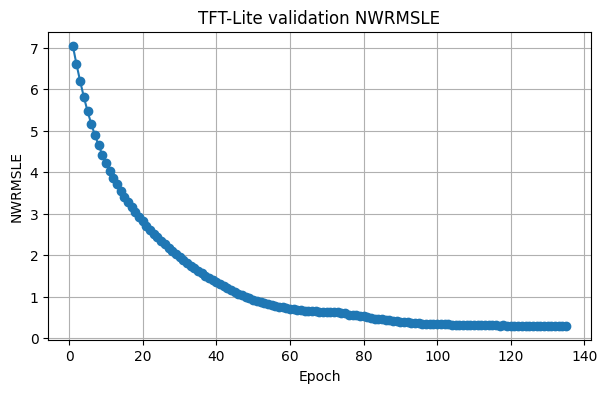

TFT-Lite best validation NWRMSLE: 0.29857027530670166


In [43]:
tft_model, tft_history, tft_best_score = train_tft(
    tft_model,
    train_tft_loader,
    valid_tft_loader,
    device=DEVICE,
    epochs=200,
    lr=1e-3,
    wd=1e-4,
    patience=4,
)

display(tft_history)

plt.figure(figsize=(7, 4))
plt.plot(tft_history["epoch"], tft_history["valid_NWRMSLE"], marker="o")
plt.title("TFT-Lite validation NWRMSLE")
plt.xlabel("Epoch")
plt.ylabel("NWRMSLE")
plt.grid(True)
plt.show()

print("TFT-Lite best validation NWRMSLE:", tft_best_score)
results = {}
results = [r for r in results if r["model"] not in ["MiniTFT", "TFT-Lite"]]
results.append({
    "model": "TFT-Lite",
    "NWRMSLE": float(tft_best_score),
})

In [44]:
# =========================================================
# Визуализация обучения TFT и сравнение разных конфигураций
# =========================================================
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. График одной истории обучения
# ---------------------------------------------------------
def plot_tft_training_history(history_df, title="TFT training history"):
    df = history_df.copy().sort_values("epoch").reset_index(drop=True)

    best_idx = df["valid_NWRMSLE"].idxmin()
    best_epoch = int(df.loc[best_idx, "epoch"])
    best_metric = float(df.loc[best_idx, "valid_NWRMSLE"])
    best_valid_loss = float(df.loc[best_idx, "valid_loss"])

    fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

    # --- Верхний график: loss + metric
    ax1 = axes[0]
    ax1.plot(df["epoch"], df["train_loss"], marker="o", label="train_loss")
    ax1.plot(df["epoch"], df["valid_loss"], marker="o", label="valid_loss")
    ax1.set_ylabel("Loss")
    ax1.grid(True, alpha=0.3)
    ax1.axvline(best_epoch, linestyle="--", alpha=0.7)

    ax1b = ax1.twinx()
    ax1b.plot(df["epoch"], df["valid_NWRMSLE"], marker="s", label="valid_NWRMSLE")
    ax1b.set_ylabel("NWRMSLE")

    ax1b.scatter([best_epoch], [best_metric], s=80)
    ax1b.annotate(
        f"best NWRMSLE={best_metric:.5f}\nepoch={best_epoch}",
        xy=(best_epoch, best_metric),
        xytext=(10, 10),
        textcoords="offset points"
    )

    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax1b.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")

    # --- Нижний график: learning rate
    ax2 = axes[1]
    if "lr" in df.columns:
        ax2.plot(df["epoch"], df["lr"], marker="o", label="lr")
        ax2.set_ylabel("Learning rate")
        ax2.set_xlabel("Epoch")
        ax2.grid(True, alpha=0.3)
        ax2.axvline(best_epoch, linestyle="--", alpha=0.7)
        ax2.legend(loc="upper right")
    else:
        ax2.text(0.5, 0.5, "Column 'lr' not found", ha="center", va="center")
        ax2.set_xlabel("Epoch")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

    print(f"Best epoch: {best_epoch}")
    print(f"Best valid_NWRMSLE: {best_metric:.6f}")
    print(f"Valid loss at best epoch: {best_valid_loss:.6f}")


# ---------------------------------------------------------
# 2. Короткий summary одного запуска
# ---------------------------------------------------------
def summarize_run(history_df, run_name, extra_params=None):
    df = history_df.copy().sort_values("epoch").reset_index(drop=True)
    best_idx = df["valid_NWRMSLE"].idxmin()

    summary = {
        "run_name": run_name,
        "best_epoch": int(df.loc[best_idx, "epoch"]),
        "best_valid_nwrmsle": float(df.loc[best_idx, "valid_NWRMSLE"]),
        "best_valid_loss": float(df.loc[best_idx, "valid_loss"]),
        "last_epoch": int(df["epoch"].max()),
        "last_valid_nwrmsle": float(df.iloc[-1]["valid_NWRMSLE"]),
        "last_valid_loss": float(df.iloc[-1]["valid_loss"]),
    }

    if "train_loss" in df.columns:
        summary["last_train_loss"] = float(df.iloc[-1]["train_loss"])
    if "lr" in df.columns:
        summary["last_lr"] = float(df.iloc[-1]["lr"])

    if extra_params is not None:
        summary.update(extra_params)

    return summary


# ---------------------------------------------------------
# 3. Сравнение summary разных запусков
# ---------------------------------------------------------
def plot_runs_comparison(runs_summary, sort_by="best_valid_nwrmsle", title="TFT runs comparison"):
    df = pd.DataFrame(runs_summary).copy()
    df = df.sort_values(sort_by, ascending=True).reset_index(drop=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    axes[0].bar(df["run_name"], df["best_valid_nwrmsle"])
    axes[0].set_title("Best validation NWRMSLE")
    axes[0].set_ylabel("NWRMSLE")
    axes[0].tick_params(axis="x", rotation=45)

    axes[1].bar(df["run_name"], df["best_epoch"])
    axes[1].set_title("Best epoch")
    axes[1].set_ylabel("Epoch")
    axes[1].tick_params(axis="x", rotation=45)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

    return df


# ---------------------------------------------------------
# 4. Наложение нескольких историй на один график
# ---------------------------------------------------------
def plot_multiple_histories(histories, metric_col="valid_NWRMSLE", title="Runs comparison by epochs"):
    plt.figure(figsize=(12, 6))

    for run_name, hist_df in histories.items():
        df = hist_df.copy().sort_values("epoch")
        plt.plot(df["epoch"], df[metric_col], marker="o", label=run_name)

    plt.xlabel("Epoch")
    plt.ylabel(metric_col)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------
# 5. Наложение loss-кривых нескольких запусков
# ---------------------------------------------------------
def plot_multiple_losses(histories, loss_col="valid_loss", title="Validation loss comparison"):
    plt.figure(figsize=(12, 6))

    for run_name, hist_df in histories.items():
        df = hist_df.copy().sort_values("epoch")
        plt.plot(df["epoch"], df[loss_col], marker="o", label=run_name)

    plt.xlabel("Epoch")
    plt.ylabel(loss_col)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

## Универсальные графики и перебор конфигураций моделей
Функции для сравнения разных моделей и параметров, отдельного графика loss, а также Plotly-визуализации прогнозов для всех моделей.


In [48]:
# =========================================================
# 16. Универсальные инструменты для:
#    - сравнения нескольких запусков моделей/параметров
#    - графиков train/valid loss + metric
#    - Plotly-графиков прогнозов для разных моделей
# =========================================================
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go


# ---------------------------------------------------------
# A. Общая подготовка point forecast из y_pred
# ---------------------------------------------------------
def extract_point_forecast(y_pred_raw, point_mode="median", quantile_index=1):
    y_pred_raw = np.asarray(y_pred_raw)

    if y_pred_raw.ndim == 2:
        return y_pred_raw

    if y_pred_raw.ndim == 3:
        if point_mode == "median":
            if quantile_index >= y_pred_raw.shape[-1]:
                raise ValueError(
                    f"quantile_index={quantile_index} вне диапазона, "
                    f"доступно квантилей: {y_pred_raw.shape[-1]}"
                )
            return y_pred_raw[:, :, quantile_index]
        if point_mode == "mean":
            return y_pred_raw.mean(axis=-1)

    raise ValueError(
        "y_pred должен иметь shape (N, H) или (N, H, Q); "
        f"получено: {y_pred_raw.shape}"
    )


# ---------------------------------------------------------
# B. Одна функция Plotly для одной модели
# ---------------------------------------------------------
def plot_results_plotly_universal(
    preds,
    series_data=None,
    n_series=5,
    context_points=60,
    seed=42,
    point_mode="median",
    quantile_index=1,
    normalized=False,
    show=True,
):
    """
    Универсальная Plotly-функция для всех моделей.

    preds должен содержать:
    - y_true:    (N, H)
    - y_pred:    (N, H) или (N, H, Q)
    - x_y:       (N, L)
    - store_id:  (N,)
    - family_id: (N,)
    """
    required_keys = ["y_true", "y_pred", "x_y", "store_id", "family_id"]
    missing = [k for k in required_keys if k not in preds]
    if missing:
        raise ValueError(f"В preds отсутствуют ключи: {missing}")

    y_true = np.asarray(preds["y_true"])
    y_pred = extract_point_forecast(
        preds["y_pred"],
        point_mode=point_mode,
        quantile_index=quantile_index,
    )
    x_y = np.asarray(preds["x_y"])

    store_ids = np.asarray(preds["store_id"]).astype(int)
    family_ids = np.asarray(preds["family_id"]).astype(int)

    N, H = y_true.shape
    L = x_y.shape[1]
    show_ctx = int(min(context_points, L))

    rng = random.Random(seed)
    idxs = rng.sample(range(N), k=min(n_series, N))

    stats = None
    if normalized:
        if series_data is None:
            raise ValueError("Если normalized=True, нужно передать series_data")
        stats = build_stats_from_series_data(series_data)

    figs = []

    for idx in idxs:
        sid = store_ids[idx]
        fid = family_ids[idx]

        ctx_arr = x_y[idx, -show_ctx:]
        true_arr = y_true[idx]
        pred_arr = y_pred[idx]

        if normalized:
            mu, sd = stats[(sid, fid)]
            ctx_sales = denorm_to_sales(ctx_arr, mu, sd)
            true_sales = denorm_to_sales(true_arr, mu, sd)
            pred_sales = denorm_to_sales(pred_arr, mu, sd)
        else:
            ctx_sales = ctx_arr
            true_sales = true_arr
            pred_sales = pred_arr

        eps = 1e-6
        smape = float(
            np.mean(
                2.0 * np.abs(pred_sales - true_sales)
                / (np.abs(true_sales) + np.abs(pred_sales) + eps)
            )
        )

        x_ctx = np.arange(-show_ctx + 1, 1)
        x_fut = np.arange(1, H + 1)

        title = f"store_id={sid}, family_id={fid} | sMAPE={smape:.4f}"

        fig = go.Figure()
        fig.add_trace(go.Scatter(x=x_ctx, y=ctx_sales, mode="lines", name="context"))
        fig.add_trace(go.Scatter(x=x_fut, y=true_sales, mode="lines+markers", name="true"))
        fig.add_trace(go.Scatter(x=x_fut, y=pred_sales, mode="lines+markers", name="pred"))

        fig.add_vline(x=0, line_dash="dash")

        fig.update_layout(
            title=title,
            xaxis_title="relative time (0 = forecast start)",
            yaxis_title="sales",
            hovermode="x unified",
            template="plotly_white",
            width=950,
            height=380,
            legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0),
            margin=dict(l=60, r=20, t=60, b=50),
        )

        if show:
            fig.show()

        figs.append(fig)

    return figs


# ---------------------------------------------------------
# C. Plotly-сравнение нескольких моделей на одних и тех же рядах
# ---------------------------------------------------------
def plot_model_predictions_grid(
    preds_by_model,
    series_data=None,
    n_series=5,
    context_points=60,
    seed=42,
    point_mode="median",
    quantile_index=1,
    normalized_models=None,
    show=True,
):
    """
    preds_by_model = {
        "SNaive": preds_snaive,
        "TFT-Lite": preds_tft,
        "LightGBM": preds_lgb,
        ...
    }

    Возвращает словарь:
    {
        model_name: [fig1, fig2, ...]
    }
    """
    if normalized_models is None:
        normalized_models = {}

    out = {}
    for model_name, preds in preds_by_model.items():
        out[model_name] = plot_results_plotly_universal(
            preds=preds,
            series_data=series_data,
            n_series=n_series,
            context_points=context_points,
            seed=seed,
            point_mode=point_mode,
            quantile_index=quantile_index,
            normalized=normalized_models.get(model_name, False),
            show=show,
        )
    return out


# ---------------------------------------------------------
# D. График истории одного запуска: отдельно metric и отдельно loss
# ---------------------------------------------------------
def plot_training_history(
    history_df,
    run_name="run",
    metric_col="valid_NWRMSLE",
    train_loss_col="train_loss",
    valid_loss_col="valid_loss",
    lr_col="lr",
):
    df = history_df.copy().sort_values("epoch").reset_index(drop=True)

    if metric_col not in df.columns:
        raise ValueError(f"В history_df нет колонки {metric_col}")

    best_idx = df[metric_col].idxmin()
    best_epoch = int(df.loc[best_idx, "epoch"])
    best_metric = float(df.loc[best_idx, metric_col])

    nrows = 3 if lr_col in df.columns else 2
    fig, axes = plt.subplots(nrows, 1, figsize=(12, 4 * nrows), sharex=True)
    if nrows == 2:
        axes_metric, axes_loss = axes
        axes_lr = None
    else:
        axes_metric, axes_loss, axes_lr = axes

    # metric
    axes_metric.plot(df["epoch"], df[metric_col], marker="o", label=metric_col)
    axes_metric.axvline(best_epoch, linestyle="--", alpha=0.7)
    axes_metric.set_title(f"{run_name}: {metric_col}")
    axes_metric.set_ylabel(metric_col)
    axes_metric.grid(True, alpha=0.3)
    axes_metric.legend()

    # loss
    if train_loss_col in df.columns:
        axes_loss.plot(df["epoch"], df[train_loss_col], marker="o", label=train_loss_col)
    if valid_loss_col in df.columns:
        axes_loss.plot(df["epoch"], df[valid_loss_col], marker="o", label=valid_loss_col)
    axes_loss.axvline(best_epoch, linestyle="--", alpha=0.7)
    axes_loss.set_title(f"{run_name}: losses")
    axes_loss.set_ylabel("loss")
    axes_loss.grid(True, alpha=0.3)
    axes_loss.legend()

    # lr
    if axes_lr is not None:
        axes_lr.plot(df["epoch"], df[lr_col], marker="o", label=lr_col)
        axes_lr.axvline(best_epoch, linestyle="--", alpha=0.7)
        axes_lr.set_title(f"{run_name}: learning rate")
        axes_lr.set_ylabel("lr")
        axes_lr.set_xlabel("epoch")
        axes_lr.grid(True, alpha=0.3)
        axes_lr.legend()
    else:
        axes_loss.set_xlabel("epoch")

    plt.tight_layout()
    plt.show()

    print(f"[{run_name}] best epoch = {best_epoch}")
    print(f"[{run_name}] best {metric_col} = {best_metric:.6f}")


# ---------------------------------------------------------
# E. Сводка по одному запуску
# ---------------------------------------------------------
def summarize_run(
    history_df,
    run_name,
    metric_col="valid_NWRMSLE",
    extra_params=None,
):
    df = history_df.copy().sort_values("epoch").reset_index(drop=True)
    best_idx = df[metric_col].idxmin()

    row = {
        "run_name": run_name,
        "best_epoch": int(df.loc[best_idx, "epoch"]),
        "best_metric": float(df.loc[best_idx, metric_col]),
        "last_epoch": int(df["epoch"].max()),
        "last_metric": float(df.iloc[-1][metric_col]),
    }

    for col in ["train_loss", "valid_loss", "lr"]:
        if col in df.columns:
            row[f"best_{col}"] = float(df.loc[best_idx, col])
            row[f"last_{col}"] = float(df.iloc[-1][col])

    if extra_params is not None:
        row.update(extra_params)

    return row


# ---------------------------------------------------------
# F. Сравнение нескольких запусков одной модели
# ---------------------------------------------------------
def plot_runs_comparison(
    runs_summary,
    sort_by="best_metric",
    title="Runs comparison",
):
    df = pd.DataFrame(runs_summary).copy()
    if df.empty:
        raise ValueError("runs_summary пустой")

    df = df.sort_values(sort_by, ascending=True).reset_index(drop=True)
    display(df)

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    axes[0].bar(df["run_name"], df["best_metric"])
    axes[0].set_title("Best metric")
    axes[0].set_ylabel("metric")
    axes[0].tick_params(axis="x", rotation=35)

    if "best_valid_loss" in df.columns:
        axes[1].bar(df["run_name"], df["best_valid_loss"])
        axes[1].set_title("Best valid loss")
        axes[1].tick_params(axis="x", rotation=35)
    else:
        axes[1].text(0.5, 0.5, "best_valid_loss not found", ha="center", va="center")
        axes[1].set_axis_off()

    axes[2].bar(df["run_name"], df["best_epoch"])
    axes[2].set_title("Best epoch")
    axes[2].tick_params(axis="x", rotation=35)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

    return df


# ---------------------------------------------------------
# G. Общий runner для перебора гиперпараметров
# ---------------------------------------------------------
def run_experiments(
    experiments,
    build_model_fn,
    train_fn,
    metric_col="valid_NWRMSLE",
    plot_each=True,
):
    """
    experiments: list[dict]
        Пример:
        [
            {
                "run_name": "tft_d36_h96_do02_lr1e4",
                "model_params": {...},
                "train_params": {...},
                "extra_params": {...},
            },
            ...
        ]

    build_model_fn(model_params) -> model
    train_fn(model, **train_params) -> (model, history_df, best_score)
    """
    all_runs = []
    trained_models = {}
    histories = {}

    for exp in experiments:
        run_name = exp["run_name"]
        model_params = exp.get("model_params", {})
        train_params = exp.get("train_params", {})
        extra_params = exp.get("extra_params", {})

        print("=" * 90)
        print(f"RUN: {run_name}")
        print("model_params:", model_params)
        print("train_params:", train_params)

        model = build_model_fn(model_params)
        model, history_df, best_score = train_fn(model, **train_params)

        trained_models[run_name] = model
        histories[run_name] = history_df

        summary = summarize_run(
            history_df=history_df,
            run_name=run_name,
            metric_col=metric_col,
            extra_params=extra_params | model_params | train_params,
        )
        summary["returned_best_score"] = float(best_score)
        all_runs.append(summary)

        if plot_each:
            plot_training_history(
                history_df=history_df,
                run_name=run_name,
                metric_col=metric_col,
            )

    summary_df = plot_runs_comparison(
        all_runs,
        sort_by="best_metric",
        title="Experiments comparison",
    )
    return trained_models, histories, summary_df


# ---------------------------------------------------------
# H. Конфиги для TFT-Lite: примеры готового перебора
# ---------------------------------------------------------
def build_tft_model_from_params(model_params):
    params = {
        "L": ENC_LEN,
        "H": HORIZON,
        "static_cardinalities": static_cardinalities,
        "past_cov_dim": len(past_cov_cols),
        "known_dim": len(known_future_cols),
        "d_static": 8,
        "d_model": 48,
        "hidden_dim": 96,
        "nhead": 4,
        "dropout": 0.2,
    }
    params.update(model_params)
    return TFTLite(**params).to(DEVICE)


def train_tft_from_params(model, **train_params):
    params = {
        "train_loader": train_tft_loader,
        "valid_loader": valid_tft_loader,
        "device": DEVICE,
        "epochs": 200,
        "lr": 1e-3,
        "wd": 1e-4,
        "patience": 4,
    }
    params.update(train_params)
    return train_tft(model, **params)


In [49]:
import matplotlib.pyplot as plt

def plot_training_curves(history_df, title="Model training history"):
    fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=True)

    # 1. Метрика
    axes[0].plot(history_df["epoch"], history_df["valid_NWRMSLE"], marker="o", label="valid_NWRMSLE")
    best_idx = history_df["valid_NWRMSLE"].idxmin()
    best_epoch = history_df.loc[best_idx, "epoch"]
    best_metric = history_df.loc[best_idx, "valid_NWRMSLE"]

    axes[0].axvline(best_epoch, linestyle="--", alpha=0.7, label=f"best epoch = {best_epoch}")
    axes[0].set_title(f"{title}: validation metric")
    axes[0].set_ylabel("NWRMSLE")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    # 2. Loss
    axes[1].plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train_loss")
    axes[1].plot(history_df["epoch"], history_df["valid_loss"], marker="o", label="valid_loss")
    axes[1].axvline(best_epoch, linestyle="--", alpha=0.7)
    axes[1].set_title(f"{title}: losses")
    axes[1].set_ylabel("loss")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    # 3. LR
    if "lr" in history_df.columns:
        axes[2].plot(history_df["epoch"], history_df["lr"], marker="o", label="lr")
        axes[2].axvline(best_epoch, linestyle="--", alpha=0.7)
        axes[2].set_title(f"{title}: learning rate")
        axes[2].set_ylabel("lr")
        axes[2].grid(True, alpha=0.3)
        axes[2].legend()

    axes[2].set_xlabel("epoch")
    plt.tight_layout()
    plt.show()

    print(f"Best epoch: {best_epoch}")
    print(f"Best valid_NWRMSLE: {best_metric:.6f}")

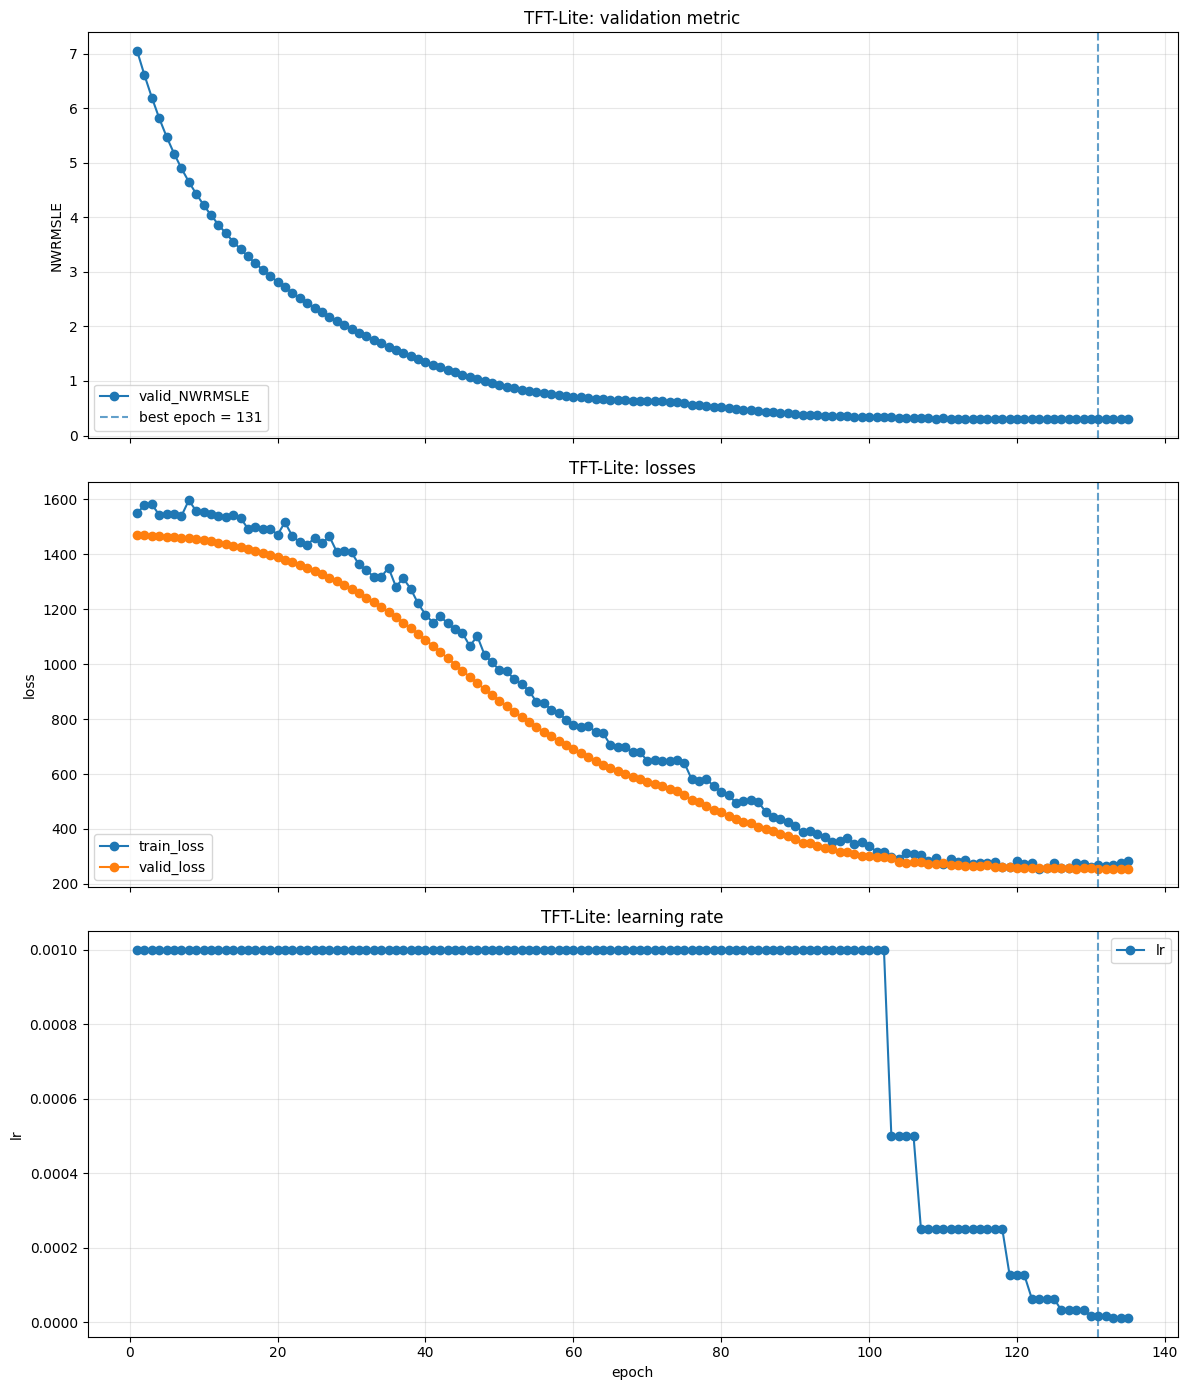

Best epoch: 131
Best valid_NWRMSLE: 0.298570


In [50]:
plot_training_curves(tft_history, title="TFT-Lite")